<a href="https://colab.research.google.com/github/joao-araujoo/calculo-numerico/blob/main/Atividade_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade II - Cálculo Numérico - Noturno - Profa. Dra. Raquel Lobosco

Rafael Augusto Guimaraes da Silva  
Joao Pedro Araujo Costa

# 1. Verificação da estabilidade

O problema representa um fluido entre duas placas paralelas separadas por H = 0,01 m, com viscosidade cinemática ν = 10^-4 m²/s.

A placa em y = 0 se move a U = 1 m/s e a placa em y = H permanece parada.

O modelo usado no enunciado pode ser escrito de forma simples como:

du/dt = ν · d²u/dy²

Usando Euler explícito no tempo e diferenças finitas centrais no espaço, a atualização de cada ponto depende do próprio valor e dos seus dois vizinhos. O parâmetro que controla a estabilidade é:

**r = (ν · Δt) / Δy²**

Para este esquema, precisamos respeitar:

**r ≤ 0,5**

Na malha original temos 21 pontos. Então:

Δy = 0,01 / (21 - 1) = 0,0005 m

Com esse espaçamento, o maior passo de tempo permitido é:

Δt máximo = Δy² / (2 · ν) = 0,00125 s

Antes de rodar qualquer simulação já esperamos que Δt = 0,001 s seja estável e que Δt = 0,002 s seja instável.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

H = 0.01
NU = 1e-4
U = 1.0

pontos_original = 21
dy_original = H / (pontos_original - 1)
dt_max_original = dy_original**2 / (2 * NU)

linhas = []

for caso, dt in [("A", 0.001), ("B", 0.002)]:
    r = NU * dt / dy_original**2

    linhas.append({
        "Caso": caso,
        "Δt (s)": dt,
        "Δy (m)": dy_original,
        "r": r,
        "Classificação": "Estável" if r <= 0.5 else "Instável",
    })

tabela_estabilidade = pd.DataFrame(linhas)

print(f"Δy = {dy_original:.7f} m")
print(f"Δt máximo = {dt_max_original:.7f} s")
print()

display(
    tabela_estabilidade.style
    .hide(axis="index")
    .format({
        "Δt (s)": "{:.6f}",
        "Δy (m)": "{:.7f}",
        "r": "{:.1f}",
    })
    .set_caption("Classificação teórica dos dois passos de tempo")
)

Δy = 0.0005000 m
Δt máximo = 0.0012500 s



Caso,Δt (s),Δy (m),r,Classificação
A,0.001000,0.0005000,0.4,Estável
B,0.002000,0.0005000,0.8,Instável


No Caso A, r = 0,4, então a condição **r ≤ 0,5** é satisfeita.

No Caso B, r = 0,8, então o método passa do limite de estabilidade.

Isso é importante porque a causa do problema já aparece na análise matemática, antes mesmo de existir overflow no computador.

# 2. Detecção de overflow

Agora executamos as quatro combinações pedidas: float32 e float64 com os dois valores de Δt.

A função abaixo é praticamente a mesma proposta no enunciado. Mantivemos a detecção de overflow e de operações inválidas, mas também guardamos algumas informações para montar as tabelas e os gráficos depois.

In [15]:
def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    '''Simula a difusão de velocidade e interrompe se ocorrer falha numérica.'''

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    r = tipo(NU * dt / dy**2)
    dois = tipo(2)

    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(U)
    u[-1] = tipo(0)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]

    falha = None
    erro = None

    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()

                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:]
                        - dois * u[1:-1]
                        + u[:-2]
                    )
                )

                novo[0] = tipo(U)
                novo[-1] = tipo(0)

            except FloatingPointError as exc:
                falha = passo
                erro = str(exc)
                break

            u = novo

            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    return {
        "y": y,
        "u": u,
        "tempos": np.asarray(tempos),
        "maximos": np.asarray(maximos),
        "r": float(r),
        "falha": falha,
        "erro": erro,
        "dy": dy,
        "dt": dt,
        "tipo": tipo.__name__,
        "pontos": pontos,
        "tempo_final": tempos[-1],
    }


print(f"Maior float32: {np.finfo(np.float32).max:.3e}")
print(f"Maior float64: {np.finfo(np.float64).max:.3e}")

Maior float32: 3.403e+38
Maior float64: 1.798e+308


In [4]:
resultados = {}
linhas = []

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, Δt={dt}"
        resultado = simular(dt=dt, tipo=tipo, passos=2000, pontos=21)
        resultados[nome] = resultado

        if resultado["falha"] is None:
            overflow = "Não"
            iteracao = "—"
            tempo_falha = "—"
        else:
            overflow = "Sim"
            iteracao = resultado["falha"]
            tempo_falha = resultado["falha"] * dt

        linhas.append({
            "Tipo numérico": tipo.__name__,
            "Δt (s)": dt,
            "r": resultado["r"],
            "Estabilidade": "Estável" if resultado["r"] <= 0.5 else "Instável",
            "Overflow": overflow,
            "Iteração da falha": iteracao,
            "Tempo da falha (s)": tempo_falha,
        })

tabela_testes = pd.DataFrame(linhas)

display(
    tabela_testes.style
    .hide(axis="index")
    .format({
        "Δt (s)": "{:.3f}",
        "r": "{:.1f}",
    })
    .set_caption("Resultados dos quatro testes")
)

print()
for nome, resultado in resultados.items():
    if resultado["falha"] is None:
        print(f"{nome}: completou os 2000 passos sem overflow.")
    else:
        print(
            f"{nome}: falhou no passo {resultado['falha']} "
            f"(t = {resultado['falha'] * resultado['dt']:.3f} s)."
        )

Tipo numérico,Δt (s),r,Estabilidade,Overflow,Iteração da falha,Tempo da falha (s)
float32,0.001,0.4,Estável,Não,—,—
float32,0.002,0.8,Instável,Sim,121,0.242000
float64,0.001,0.4,Estável,Não,—,—
float64,0.002,0.8,Instável,Sim,917,1.834000



float32, Δt=0.001: completou os 2000 passos sem overflow.
float32, Δt=0.002: falhou no passo 121 (t = 0.242 s).
float64, Δt=0.001: completou os 2000 passos sem overflow.
float64, Δt=0.002: falhou no passo 917 (t = 1.834 s).


Os dois testes com r = 0,4 terminam os 2000 passos normalmente.

Já nos testes com r = 0,8, a solução começa a crescer e depois estoura o limite do tipo numérico. Na nossa execução, o float32 falhou no passo 121 e o float64 no passo 917.

Esse resultado já mostra uma diferença importante: o float64 aguenta números muito maiores, então ele demora mais para atingir overflow. Mesmo assim, a simulação continua instável nos dois tipos.

# 3. Interpretação física

Neste problema a velocidade física deve ficar entre 0 e 1 m/s. Portanto, não precisamos esperar aparecer inf ou uma exceção para saber que existe algo errado: se a maior velocidade começa a crescer muito acima de 1 m/s, a solução já deixou de representar o escoamento.

Para visualizar os quatro casos juntos, usamos o logaritmo do maior valor de |u|. Isso deixa possível enxergar na mesma escala desde a velocidade física de 1 m/s até valores enormes próximos do limite do float64.

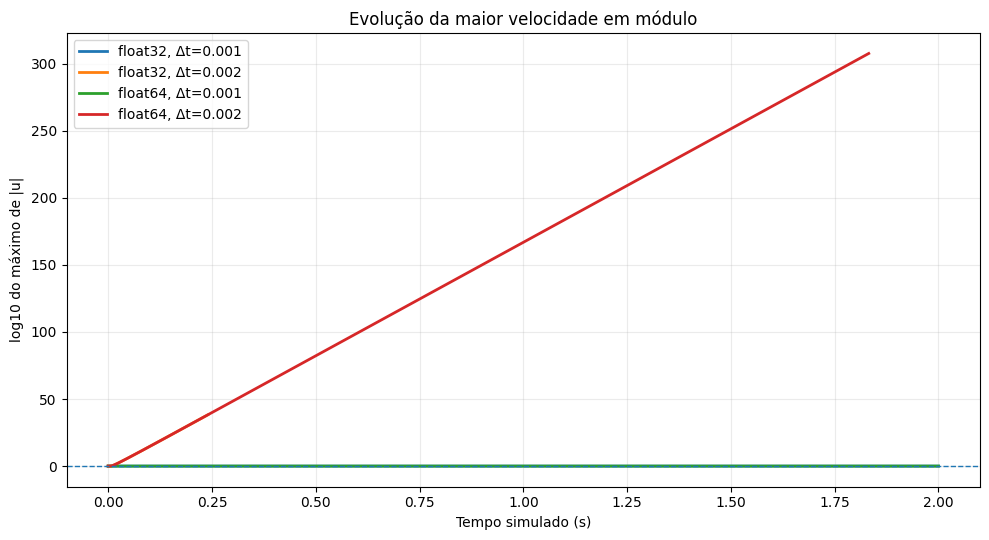

In [14]:
plt.figure(figsize=(10, 5.5))

for nome, resultado in resultados.items():
    log_max = np.log10(resultado["maximos"])

    plt.plot(
        resultado["tempos"],
        log_max,
        linewidth=2,
        label=nome,
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Tempo simulado (s)")
plt.ylabel("log10 do máximo de |u|")
plt.title("Evolução da maior velocidade em módulo")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

O comportamento dos dois casos estáveis faz sentido: o maior valor de velocidade continua sendo 1 m/s, que é justamente a velocidade imposta na placa móvel.

Nos casos com r = 0,8, a curva cresce muitas ordens de grandeza em pouco tempo. Isso não representa uma aceleração real do fluido. O que está crescendo são as oscilações numéricas do método.

Dá para entender isso olhando para os pesos usados na atualização. Eles são:

r, (1 - 2r) e r

Quando **r ≤ 0,5**, esses pesos não ficam negativos e somam 1, então a atualização se comporta como uma média ponderada.

Para r = 0,8, o peso central vira:

1 - 2 · 0,8 = -0,6

A partir daí pequenas perturbações podem ser amplificadas de uma iteração para outra. O overflow aparece depois, mas a solução já estava errada muito antes.

# 4. Capacidade de representação: float32 x float64

Os limites dos dois tipos são muito diferentes:

- float32: aproximadamente 3,4 × 10^38
- float64: aproximadamente 1,8 × 10^308

Essa diferença explica por que o float64 demora muito mais para falhar no caso instável.

In [6]:
tabela_tipos = pd.DataFrame([
    {
        "Tipo": "float32",
        "Maior valor finito": np.finfo(np.float32).max,
        "Epsilon": np.finfo(np.float32).eps,
        "Passo da falha com Δt=0,002": resultados["float32, Δt=0.002"]["falha"],
    },
    {
        "Tipo": "float64",
        "Maior valor finito": np.finfo(np.float64).max,
        "Epsilon": np.finfo(np.float64).eps,
        "Passo da falha com Δt=0,002": resultados["float64, Δt=0.002"]["falha"],
    },
])

display(
    tabela_tipos.style
    .hide(axis="index")
    .format({
        "Maior valor finito": "{:.3e}",
        "Epsilon": "{:.3e}",
    })
    .set_caption("Capacidade de representação e momento da falha")
)

Tipo,Maior valor finito,Epsilon,"Passo da falha com Δt=0,002"
float32,3.403e+38,1.192e-07,121
float64,1.798e+308,2.220e-16,917


Trocar float32 por float64 não corrige a instabilidade.

O valor de r depende de ν, Δt e Δy, e nenhum desses três valores muda quando apenas trocamos o tipo numérico. O float64 só oferece uma faixa de representação muito maior, então a sequência instável consegue crescer por mais iterações antes de ultrapassar o limite da máquina.

Em outras palavras: aumentar a precisão adia o overflow, mas não conserta o método.

# 5. Refinamento da malha

Agora aumentamos a malha de 21 para 41 pontos.

O novo espaçamento fica:

Δy = 0,01 / (41 - 1) = 0,00025 m

Com esse valor, o novo limite de estabilidade passa a ser:

Δt máximo = 0,0003125 s

Aqui aparece um detalhe importante: ao reduzir Δy pela metade, Δy² fica quatro vezes menor. Por isso, para manter o mesmo valor de r, precisamos reduzir Δt aproximadamente por um fator de quatro.

Primeiro fazemos exatamente o que o enunciado pede e mantemos Δt = 0,001 s. Depois repetimos com Δt = 0,00025 s, que fica abaixo do novo limite e mantém r = 0,4.

In [7]:
pontos_refinados = 41
dy_refinado = H / (pontos_refinados - 1)
dt_max_refinado = dy_refinado**2 / (2 * NU)

dt_mantido = 0.001
dt_corrigido = 0.00025

r_mantido = NU * dt_mantido / dy_refinado**2
r_corrigido = NU * dt_corrigido / dy_refinado**2

print(f"Novo Δy = {dy_refinado:.8f} m")
print(f"Novo Δt máximo = {dt_max_refinado:.8f} s")
print(f"Com Δt = {dt_mantido:.5f} s, r = {r_mantido:.2f}")
print(f"Com Δt = {dt_corrigido:.5f} s, r = {r_corrigido:.2f}")

Novo Δy = 0.00025000 m
Novo Δt máximo = 0.00031250 s
Com Δt = 0.00100 s, r = 1.60
Com Δt = 0.00025 s, r = 0.40


In [13]:
refinado_instavel = simular(
    dt=dt_mantido,
    tipo=np.float64,
    passos=2000,
    pontos=41,
)

refinado_estavel = simular(
    dt=dt_corrigido,
    tipo=np.float64,
    passos=2000,
    pontos=41,
)

comparacao_refino = pd.DataFrame([
    {
        "Pontos": 21,
        "Δy (m)": dy_original,
        "Δt (s)": 0.001,
        "r": NU * 0.001 / dy_original**2,
        "Resultado": "Estável",
        "Falha": "—",
    },
    {
        "Pontos": 41,
        "Δy (m)": dy_refinado,
        "Δt (s)": dt_mantido,
        "r": refinado_instavel["r"],
        "Resultado": "Instável",
        "Falha": refinado_instavel["falha"],
    },
    {
        "Pontos": 41,
        "Δy (m)": dy_refinado,
        "Δt (s)": dt_corrigido,
        "r": refinado_estavel["r"],
        "Resultado": "Estável",
        "Falha": "—",
    },
])

display(
    comparacao_refino.style
    .hide(axis="index")
    .format({
        "Δy (m)": "{:.8f}",
        "Δt (s)": "{:.5f}",
        "r": "{:.2f}",
    })
    .set_caption("Efeito do refinamento da malha")
)

Pontos,Δy (m),Δt (s),r,Resultado,Falha
21,0.00050000,0.00100,0.40,Estável,—
41,0.00025000,0.00100,1.60,Instável,426
41,0.00025000,0.00025,0.40,Estável,—


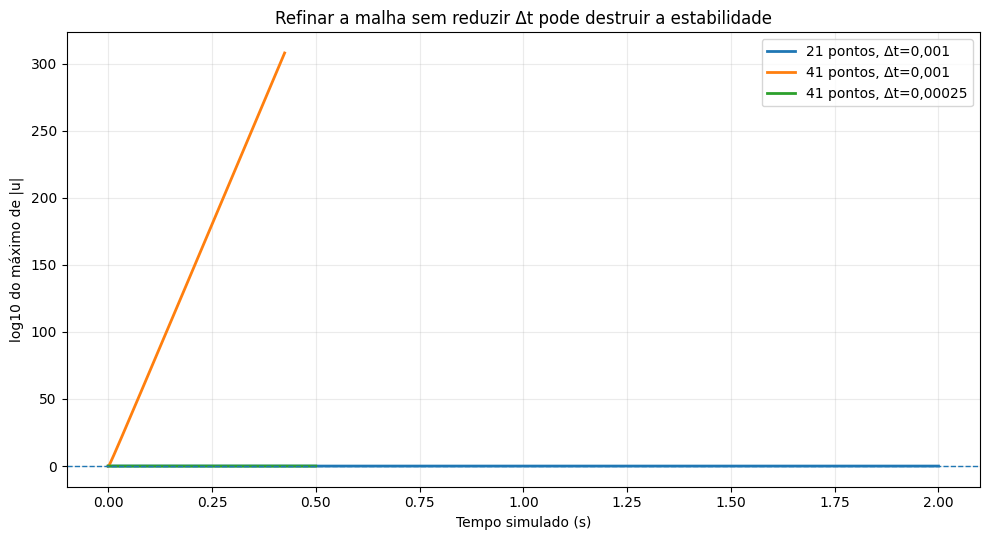

In [9]:
casos_refino = {
    "21 pontos, Δt=0,001": resultados["float64, Δt=0.001"],
    "41 pontos, Δt=0,001": refinado_instavel,
    "41 pontos, Δt=0,00025": refinado_estavel,
}

plt.figure(figsize=(10, 5.5))

for nome, resultado in casos_refino.items():
    plt.plot(
        resultado["tempos"],
        np.log10(resultado["maximos"]),
        linewidth=2,
        label=nome,
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Tempo simulado (s)")
plt.ylabel("log10 do máximo de |u|")
plt.title("Refinar a malha sem reduzir Δt pode destruir a estabilidade")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

Com 41 pontos e Δt = 0,001 s, obtemos r = 1,6. Ou seja, um passo de tempo que funcionava na malha de 21 pontos deixa de funcionar quando a malha é refinada.

Ao reduzir o passo para Δt = 0,00025 s, voltamos para r = 0,4 e a simulação completa os 2000 passos sem overflow.

Esse teste foi o que deixou mais claro para nós que uma malha espacial mais fina não significa automaticamente uma simulação melhor. Se o método é explícito, o passo de tempo também precisa acompanhar o refinamento.

# 6. Verificação do perfil de velocidade

Para o regime estacionário, o enunciado fornece a relação:

**u_est(y) = U · (1 - y/H)**

Vamos usar uma execução estável com 21 pontos, float64, Δt = 0,001 s e 2000 passos. Isso corresponde a um tempo simulado de 2 s.

Depois calculamos a maior diferença entre o perfil numérico e o estacionário:

**E_inf = maior valor de |u_numérico - u_estacionário|**

In [10]:
perfil = simular(
    dt=0.001,
    tipo=np.float64,
    passos=2000,
    pontos=21,
)

y = perfil["y"]
u_numerico = perfil["u"]
u_estacionario = U * (1 - y / H)

erro_ponto = np.abs(u_numerico - u_estacionario)
erro_infinito = float(np.max(erro_ponto))

print(f"Tempo simulado: {perfil['tempo_final']:.3f} s")
print(f"E∞ = {erro_infinito:.6e} m/s")

Tempo simulado: 2.000 s
E∞ = 1.605312e-09 m/s


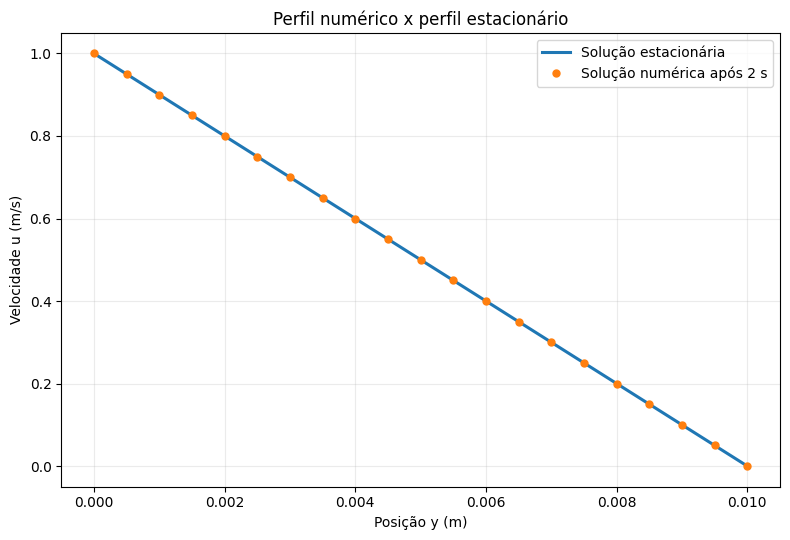

In [11]:
plt.figure(figsize=(8, 5.5))

plt.plot(
    y,
    u_estacionario,
    linewidth=2.2,
    label="Solução estacionária",
)

plt.plot(
    y,
    u_numerico,
    marker="o",
    linestyle="none",
    markersize=5,
    label="Solução numérica após 2 s",
)

plt.xlabel("Posição y (m)")
plt.ylabel("Velocidade u (m/s)")
plt.title("Perfil numérico x perfil estacionário")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
tabela_perfil = pd.DataFrame({
    "y (m)": y,
    "u numérico (m/s)": u_numerico,
    "u estacionário (m/s)": u_estacionario,
    "|erro| (m/s)": erro_ponto,
})

display(
    tabela_perfil.style
    .hide(axis="index")
    .format({
        "y (m)": "{:.4f}",
        "u numérico (m/s)": "{:.8f}",
        "u estacionário (m/s)": "{:.8f}",
        "|erro| (m/s)": "{:.3e}",
    })
    .set_caption("Comparação ponto a ponto do perfil final")
)

y (m),u numérico (m/s),u estacionário (m/s),|erro| (m/s)
0.0000,1.00000000,1.00000000,0.000e+00
0.0005,0.95000000,0.95000000,2.511e-10
0.0010,0.90000000,0.90000000,4.961e-10
0.0015,0.85000000,0.85000000,7.288e-10
0.0020,0.80000000,0.80000000,9.436e-10
0.0025,0.75000000,0.75000000,1.135e-09
0.0030,0.70000000,0.70000000,1.299e-09
0.0035,0.65000000,0.65000000,1.430e-09
0.0040,0.60000000,0.60000000,1.527e-09
0.0045,0.55000000,0.55000000,1.586e-09


Depois de 2 s, o erro máximo foi da ordem de 10^-9 m/s. No gráfico, os pontos da solução numérica praticamente ficam em cima da reta estacionária.

Por isso consideramos que, para esta malha e este passo de tempo, 2 s foi suficiente para o transiente praticamente desaparecer.

Também é importante lembrar que essa reta descreve apenas o regime estacionário. No começo da simulação, o fluido ainda está recebendo movimento da placa por efeito viscoso, então o perfil não deveria nascer linear.

# Síntese do que aconteceu

A sequência observada nos testes foi esta:

Refinar a malha → diminuir Δy → diminuir o Δt máximo permitido → se Δt não mudar, r aumenta → aparece instabilidade → a velocidade cresce sem sentido físico → pode ocorrer overflow.

O caminho para corrigir o problema foi justamente reduzir o passo de tempo até voltar a respeitar **r ≤ 0,5**.

| Situação | r | Resultado |
|---|---:|---|
| 21 pontos, Δt = 0,001 | 0,4 | estável |
| 21 pontos, Δt = 0,002 | 0,8 | instável |
| 41 pontos, Δt = 0,001 | 1,6 | instável |
| 41 pontos, Δt = 0,00025 | 0,4 | estável |

# 7. Conclusão

Nesta atividade vimos que o overflow não é a causa da simulação dar errado, mas sim uma consequência que aparece depois que a solução já ficou instável. Com 21 pontos, Δt = 0,001 s deu r = 0,4 e funcionou normalmente, enquanto Δt = 0,002 s deu r = 0,8 e fez as velocidades crescerem sem sentido físico. O float64 demorou mais para falhar que o float32, mas isso só aconteceu porque ele consegue representar números muito maiores; a instabilidade continuou exatamente a mesma.

O refinamento da malha mostrou outro ponto importante. Quando passamos de 21 para 41 pontos, o espaçamento caiu pela metade, mas o limite do passo de tempo caiu para um quarto do valor anterior. Mantendo Δt = 0,001 s, o valor de r subiu para 1,6 e a simulação ficou ainda mais instável. Ao usar Δt = 0,00025 s, voltamos para r = 0,4 e o problema foi corrigido.

Por fim, no caso estável executado por 2 s, o perfil numérico praticamente coincidiu com a solução estacionária e o erro máximo ficou da ordem de 10^-9 m/s. Então a alteração que realmente resolveu a falha nesta simulação foi escolher um passo de tempo compatível com a malha, respeitando a condição de estabilidade do método.